<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-Individual-Project/blob/main/EMSC_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
import numpy as np
import matplotlib.pyplot as plt

In [135]:
# Define constants
sigma            = 5.67e-8
C_s = 0.7 * 1025 * 4000 * 50 + 0.3 * 1000 * 800 * 2
C_a1 = 0.7e7
C_a2 = 1.5e7
C_d = 1025 * 4000 * 3800              # ≈ 1.56e10 J/m²/K  deep ocean
C0              = 280
CO2_growth_rate = 2.0
epsilon         = 0.484
gamma           = 0.5                  # W/m²/K  surface–deep ocean exchange
alpha_min = 0.20
alpha_max = 0.80
T_ice     = 263.15   # K — centre of ice transition (~-10°C)
delta_T   = 10.0     # K — transition width
A_cycle = 0.5    # W/m²  — amplitude (half of ~1 W/m² peak-to-peak observed TSI range)
P_cycle = 11.0   # years — solar cycle period
S0 = 1361


years   = 500
dt      = 0.001
n_steps = int(years / dt)
seconds_per_year = 365 * 24 * 3600
dt_sec  = dt * seconds_per_year
time    = np.linspace(0, years, n_steps)

Ts  = np.zeros(n_steps)
Ta2 = np.zeros(n_steps)
Ta1 = np.zeros(n_steps)
Td  = np.zeros(n_steps)               # deep ocean

Ts[0]  = 287.41
Ta2[0] = 252.69
Ta1[0] = 229.07
Td[0]  = 287.41                        # 4°C — observed deep ocean mean

for i in range(n_steps - 1):
    t     = time[i]
    S = S0 + A_cycle * np.sin(2 * np.pi * t / P_cycle)

    alpha = alpha_max - (
    (alpha_max - alpha_min)
    / (1 + np.exp(-(Ts[i] - T_ice)/delta_T)))

    CO2   = C0 + CO2_growth_rate * t
    #CO2 = C0 + 500*(1 - np.exp(-t/200))
    if CO2 < 1:
       CO2 = 1
    F_co2 = 5.35 * np.log(CO2 / C0)

    F_volc = -2 * np.exp(-(t-200)**2 / 4)

    noise = np.random.normal(0, 1)

    dTs_dt = (
          (1 - alpha) * S / 4
        + epsilon * sigma * Ta2[i]**4
        + (1 - epsilon) * epsilon * sigma * Ta1[i]**4
        - sigma * Ts[i]**4
        + F_co2
        - gamma * (Ts[i] - Td[i])
        + F_volc
        + noise
      ) / C_s

    dTa2_dt = (
          epsilon * sigma * Ts[i]**4
        + epsilon**2 * sigma * Ta1[i]**4
        - 2 * epsilon * sigma * Ta2[i]**4
      ) / C_a2

    dTa1_dt = (
          epsilon * (1 - epsilon) * sigma * Ts[i]**4
        + epsilon**2 * sigma * Ta2[i]**4
        - 2 * epsilon * sigma * Ta1[i]**4
      ) / C_a1

    dTd_dt = (
        gamma * (Ts[i] - Td[i])        # slow equilibration toward surface
      ) / C_d

    Ts[i+1]  = Ts[i]  + dTs_dt  * dt_sec
    Ta2[i+1] = Ta2[i] + dTa2_dt * dt_sec
    Ta1[i+1] = Ta1[i] + dTa1_dt * dt_sec
    Td[i+1]  = Td[i]  + dTd_dt  * dt_sec

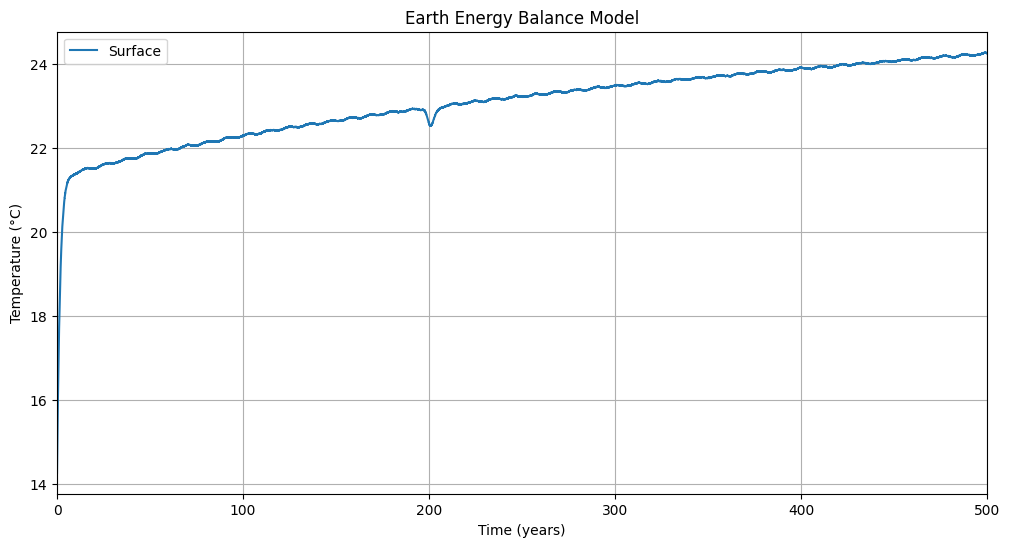

In [136]:

# Plot model

plt.figure(figsize=(12, 6))

plt.plot(time, Ts - 273.15, label='Surface')
#plt.plot(time, Ta2 - 273.15, label='Ta2')
#plt.plot(time, Ta1 - 273.15, label='Ta1')
#plt.plot(time, Td - 273.15, label='Deep Ocean')
plt.xlim(0,years)
plt.xlabel('Time (years)')
plt.ylabel('Temperature (°C)')
plt.title('Earth Energy Balance Model')

plt.legend()
plt.grid(True)

plt.show()